In [4]:
import os
import pandas as pd

import glob
import numpy as np

import torch

from model import INNLightningModule
import train

from plottingtools import plot_1d_hist, plot_2d_hist, plot_2d_res_hist
from matplotlib import pyplot as plt
import mplhep as hep
hep.style.use(hep.style.ATLAS)

In [5]:
ckpt_files = glob.glob(f"/root/work/ww-flow/logs/hww_inn_regressor-lep/log/version_0/checkpoints/*.ckpt")
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found in {ckpt_files}")
ckpt_path = ckpt_files[0]  # Use the first checkpoint found
print(f"Using checkpoint: {ckpt_path}")

Using checkpoint: /root/work/ww-flow/logs/hww_inn_regressor-lep/log/version_0/checkpoints/reg-epoch=466-val_loss=0.38.ckpt


In [6]:
# Retrieve datamodule used in training
dm, X_stdscalar, Y_stdscalar = train.main(train=False)
# Get the test dataloader
# `dm.setup()` to resample and standardize the data
# with the fix random seed to ensure no-mixing with training data
dm.setup()
test_loader = dm.test_dataloader()

# Load model from checkpoint
model = INNLightningModule.load_from_checkpoint(ckpt_path)
model.eval() # used to inference -> not for training phase

predictions = np.empty([0, dm.X.shape[1]]) # pred ww
predictions_inputs = np.empty([0, dm.Y.shape[1]]) # pred inputs
true_labels = np.empty([0, dm.X.shape[1]]) # true ww
test_features = np.empty([0, dm.Y.shape[1]]) # lvlv
sample_z = np.empty([0, model.hparams.z_dim]) # sampled z
predictions_z = np.empty([0, model.hparams.z_dim]) # predicted z

# Cache scaler parameters as NumPy arrays to avoid torch/NumPy mixed arithmetic warnings
x_scale = np.asarray(X_stdscalar.scale_)
x_mean = np.asarray(X_stdscalar.mean_)
y_scale_8 = np.asarray(Y_stdscalar.scale_[:8])
y_mean_8 = np.asarray(Y_stdscalar.mean_[:8])

# Inference loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    for batch in test_loader:
        batch_ww, batch_lvlv = batch
        cond = batch_lvlv[:, 8:]  # conditioning variables
        batch_lvlv = batch_lvlv[:, :8]
        cond = cond.to(device)
        batch_ww = batch_ww.to(device)
        batch_lvlv = batch_lvlv.to(device)

        # Match training-time forward input shape: x is padded to internal_dim.
        batch_ww_padded = torch.cat([
            batch_ww,
            torch.zeros(batch_ww.shape[0], model.inn.input_pad, device=device),
        ], dim=1)

        _z_like_tensor = torch.randn(batch_lvlv.shape[0], model.hparams.z_dim, device=device)
        # z_sample = randmultin(_z_like_tensor, device=device)
        z_sample = torch.randn_like(_z_like_tensor) # Gaussian prior
        yz = torch.cat([batch_lvlv.to(device), z_sample.to(device)], dim=1)
        lvlv_pred = model(batch_ww_padded, cond, reverse=False) # the prediction gives the inputs (y, z)
        ww_pred = model(yz, cond, reverse=True)
        z_pred = lvlv_pred[1] # predicted z

        ww_pred_np = ww_pred[:, :model.inn.x_dim].cpu().numpy()
        ww_np = batch_ww.cpu().numpy()
        lvlv_np = batch_lvlv.cpu().numpy()
        lvlv_pred_np = lvlv_pred[0].cpu().numpy() # don't include z

        ww_pred = ww_pred_np * x_scale + x_mean
        ww = ww_np * x_scale + x_mean
        lvlv = lvlv_np * y_scale_8 + y_mean_8
        lvlv_pred = lvlv_pred_np * y_scale_8 + y_mean_8

        # Store results
        predictions = np.append(predictions, ww_pred, axis=0)
        true_labels = np.append(true_labels, ww, axis=0)
        test_features = np.append(test_features[:, :8], lvlv, axis=0)
        predictions_inputs = np.append(predictions_inputs[:, :8], lvlv_pred, axis=0)
        sample_z = np.append(sample_z, z_sample.cpu().numpy(), axis=0)
        predictions_z = np.append(predictions_z, z_pred.cpu().numpy(), axis=0)

print("Inference completed.")
print(f"Test features shape: {test_features.shape}")
print(f"Predictions shape: {predictions.shape}")
print(f"True labels shape: {true_labels.shape}")

Evaluation mode, loading checkpoints...


Training objects shape: (376985, 21)
Target objects shape: (376985, 6)
Removed 117 rows with NaN or infinite values
Using 6 workers in data loading.
Loading model from checkpoint for evaluation... return datamodule
Inference completed.
Test features shape: (3768, 8)
Predictions shape: (3768, 6)
True labels shape: (3768, 6)


In [7]:
# Retrieve datamodule used in training
dm, X_stdscalar, Y_stdscalar = train.main(train=False)
# Get the test dataloader
# `dm.setup()` to resample and standardize the data
# with the fix random seed to ensure no-mixing with training data
dm.setup()
test_loader = dm.test_dataloader()

# Load model from checkpoint
model = INNLightningModule.load_from_checkpoint(ckpt_path)
model.eval() # used to inference -> not for training phase

trail_predictions = np.empty([0, dm.X.shape[1]]) # pred ww
trail_predictions_inputs = np.empty([0, dm.Y.shape[1]]) # pred inputs
trail_true_labels = np.empty([0, dm.X.shape[1]]) # true ww
trail_test_features = np.empty([0, dm.Y.shape[1]]) # lvlv
trail_sample_z = np.empty([0, model.hparams.z_dim]) # sampled z
trail_predictions_z = np.empty([0, model.hparams.z_dim]) # predicted z

# Cache scaler parameters as NumPy arrays to avoid torch/NumPy mixed arithmetic warnings
x_scale = np.asarray(X_stdscalar.scale_)
x_mean = np.asarray(X_stdscalar.mean_)
y_scale_8 = np.asarray(Y_stdscalar.scale_[:8])
y_mean_8 = np.asarray(Y_stdscalar.mean_[:8])

# Inference loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    for batch in test_loader:
        batch_ww, batch_lvlv = batch
        cond = batch_lvlv[:, 8:]  # conditioning variables
        batch_lvlv = batch_lvlv[:, :8]
        cond = cond.to(device)
        batch_ww = batch_ww.to(device)
        batch_lvlv = batch_lvlv.to(device)

        # Match training-time forward input shape: x is padded to internal_dim.
        batch_ww_padded = torch.cat([
            batch_ww,
            torch.zeros(batch_ww.shape[0], model.inn.input_pad, device=device),
        ], dim=1)

        _z_like_tensor = torch.randn(batch_lvlv.shape[0], model.hparams.z_dim, device=device)
        # z_sample = randmultin(_z_like_tensor, device=device)
        z_sample = torch.randn_like(_z_like_tensor) # Gaussian prior
        print(z_sample[1]) # Debug print to check sampled z values
        yz = torch.cat([batch_lvlv.to(device), z_sample.to(device)], dim=1)
        lvlv_pred = model(batch_ww_padded, cond, reverse=False) # the prediction gives the inputs (y, z)
        ww_pred = model(yz, cond, reverse=True)
        z_pred = lvlv_pred[1] # predicted z

        ww_pred_np = ww_pred[:, :model.inn.x_dim].cpu().numpy()
        ww_np = batch_ww.cpu().numpy()
        lvlv_np = batch_lvlv.cpu().numpy()
        lvlv_pred_np = lvlv_pred[0].cpu().numpy() # don't include z

        ww_pred = ww_pred_np * x_scale + x_mean
        ww = ww_np * x_scale + x_mean
        lvlv = lvlv_np * y_scale_8 + y_mean_8
        lvlv_pred = lvlv_pred_np * y_scale_8 + y_mean_8

        # Store results
        trail_predictions = np.append(trail_predictions, ww_pred, axis=0)
        trail_true_labels = np.append(trail_true_labels, ww, axis=0)
        trail_test_features = np.append(trail_test_features[:, :8], lvlv, axis=0)
        trail_predictions_inputs = np.append(trail_predictions_inputs[:, :8], lvlv_pred, axis=0)
        trail_sample_z = np.append(trail_sample_z, z_sample.cpu().numpy(), axis=0)
        trail_predictions_z = np.append(trail_predictions_z, z_pred.cpu().numpy(), axis=0)

print("Inference completed.")
print(f"Test features shape: {trail_test_features.shape}")
print(f"trail_Predictions shape: {trail_predictions.shape}")
print(f"True labels shape: {trail_true_labels.shape}")

Evaluation mode, loading checkpoints...
Training objects shape: (376985, 21)
Target objects shape: (376985, 6)
Removed 117 rows with NaN or infinite values
Using 6 workers in data loading.
Loading model from checkpoint for evaluation... return datamodule
tensor([ 1.2454, -1.2839,  1.1017, -2.4725,  1.3764, -0.0063, -0.5542,  0.6884],
       device='cuda:0')
tensor([-0.9238,  1.7086, -0.2847, -1.4906,  0.5783,  0.9173,  1.4583,  0.9681],
       device='cuda:0')
tensor([ 1.0867,  0.4597, -1.1684, -1.1320, -0.8339,  1.2463,  2.0166,  0.2848],
       device='cuda:0')
tensor([ 0.7834, -0.1139, -0.3357,  0.8821,  1.0723,  0.3794,  1.6500,  0.8530],
       device='cuda:0')
tensor([ 1.1081, -0.1699, -0.8081, -0.1368,  0.0982, -1.0538,  1.1764,  0.2400],
       device='cuda:0')
tensor([-0.8788, -1.4603,  0.1862, -2.2719,  0.3329, -0.2250, -0.5794,  0.4140],
       device='cuda:0')
tensor([-1.2518,  0.4757, -0.3192, -0.6698, -0.2073, -0.2332, -0.2775, -0.5028],
       device='cuda:0')
tensor([-0

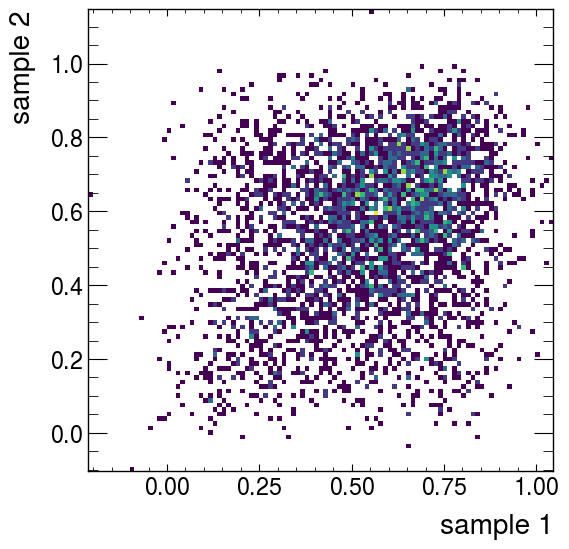

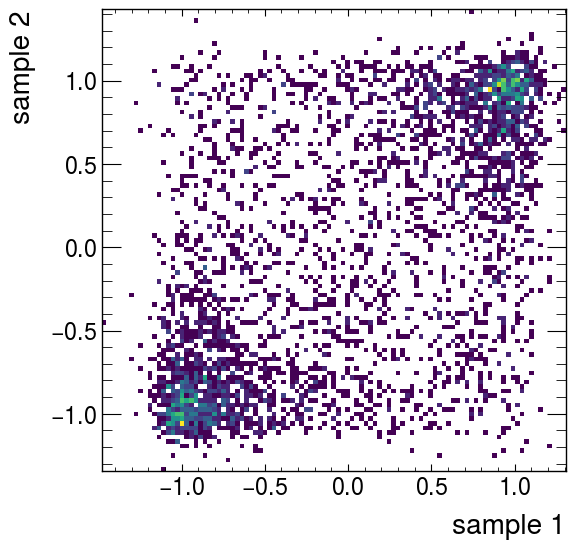

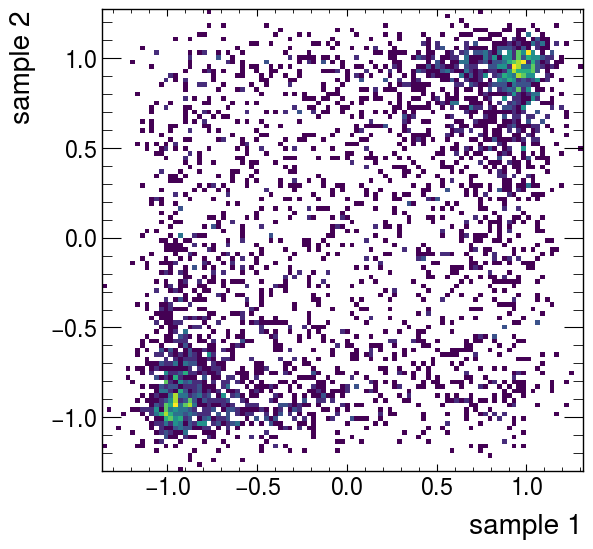

In [8]:
# test the effect of sampling z
plt.hist2d(trail_predictions[..., 0], predictions[..., 0], bins=101, cmap='viridis', cmin=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("sample 1")
plt.ylabel("sample 2")
plt.show()
plt.hist2d(trail_predictions[..., 2], predictions[..., 2], bins=101, cmap='viridis', cmin=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("sample 1")
plt.ylabel("sample 2")
plt.show()
plt.hist2d(trail_predictions[..., -1], predictions[..., -1], bins=101, cmap='viridis', cmin=1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("sample 1")
plt.ylabel("sample 2")
plt.show()

Closest sample index: 9, distance: 0.132


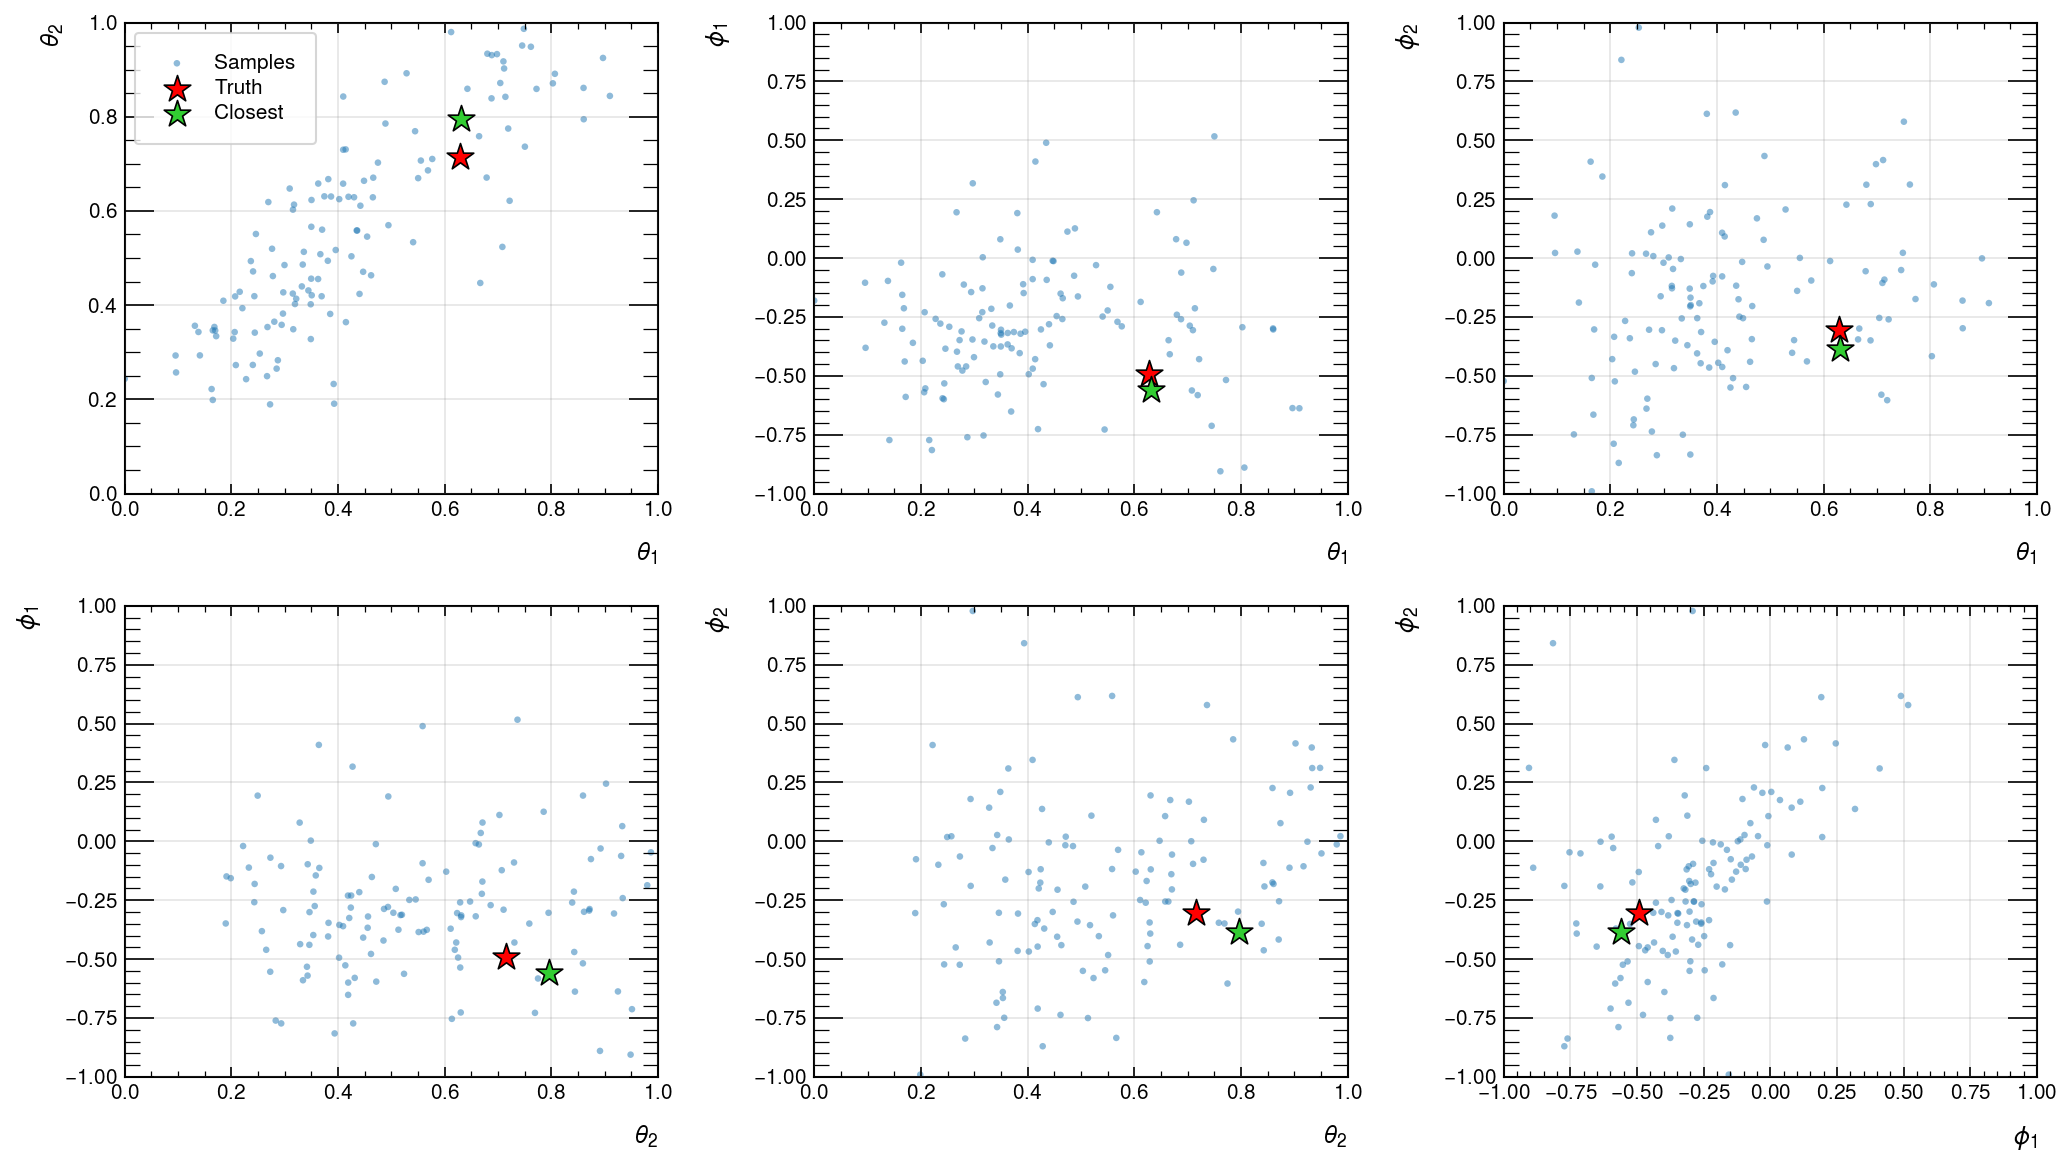

In [9]:
sample_idx = 110
n_samples = 128
pair_indices = [(0, 2), (0, 1), (0, 3), (2, 1), (2, 3), (1, 3)]
pair_labels = [r"$\theta_1$", r"$\phi_1$", r"$\theta_2$", r"$\phi_2$"]

base_lvlv = batch_lvlv[sample_idx:sample_idx + 1].to(device)
base_cond = cond[sample_idx:sample_idx + 1].to(device)
true_values = (batch_ww[sample_idx:sample_idx + 1].cpu().numpy() * x_scale + x_mean)[0]

sampled_values = []
with torch.no_grad():
    for _ in range(n_samples):
        z_sample = torch.randn(1, model.hparams.z_dim, device=device)
        yz = torch.cat([base_lvlv, z_sample], dim=1)
        pred = model(yz, base_cond, reverse=True)
        pred = pred[:, :model.inn.x_dim].cpu().numpy() * x_scale + x_mean
        pred_l0_theta = float(pred[0, 0])
        pred_l0_phi = float(np.arctan2(pred[0, 1], pred[0, 2]) / np.pi)
        pred_l1_theta = float(pred[0, 3])
        pred_l1_phi = float(np.arctan2(pred[0, 4], pred[0, 5]) / np.pi)
        
        sampled_values.append([pred_l0_theta, pred_l0_phi, pred_l1_theta, pred_l1_phi])

sampled_values = np.asarray(sampled_values, dtype=float)
true_values = np.asarray([
    true_values[0],
    np.arctan2(true_values[1], true_values[2]) / np.pi,
    true_values[3],
    np.arctan2(true_values[4], true_values[5]) / np.pi
], dtype=float)

axis_ranges = {0: (0, 1), 1: (-1, 1), 2: (0, 1), 3: (-1, 1)}
distance = np.linalg.norm(sampled_values[:, :4] - true_values[:4], axis=1)
closest_idx = np.argmin(distance)
closest_values = sampled_values[closest_idx]
print(f"Closest sample index: {closest_idx}, distance: {distance[closest_idx]:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=150)
fig.patch.set_facecolor("white")
axes = axes.ravel()
for ax, (i, j) in zip(axes, pair_indices):
    ax.scatter(sampled_values[:, i], sampled_values[:, j], s=10, alpha=0.5, color="tab:blue", edgecolors="none")
    ax.scatter(true_values[i], true_values[j], marker="*", s=180, color="red", edgecolor="black", linewidth=0.8, zorder=5)
    ax.scatter(closest_values[i], closest_values[j], marker="*", s=180, color="limegreen", edgecolor="black", linewidth=0.8, zorder=6)
    ax.set_xlim(*axis_ranges[i])
    ax.set_ylim(*axis_ranges[j])
    ax.grid(True, alpha=0.2, color="gray", linewidth=0.8)
    ax.set_xlabel(pair_labels[i], fontsize=12)
    ax.set_ylabel(pair_labels[j], fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    axes[0].legend(["Samples", "Truth", "Closest"], loc="best", fontsize=10, frameon=True)
fig.tight_layout()
plt.show()

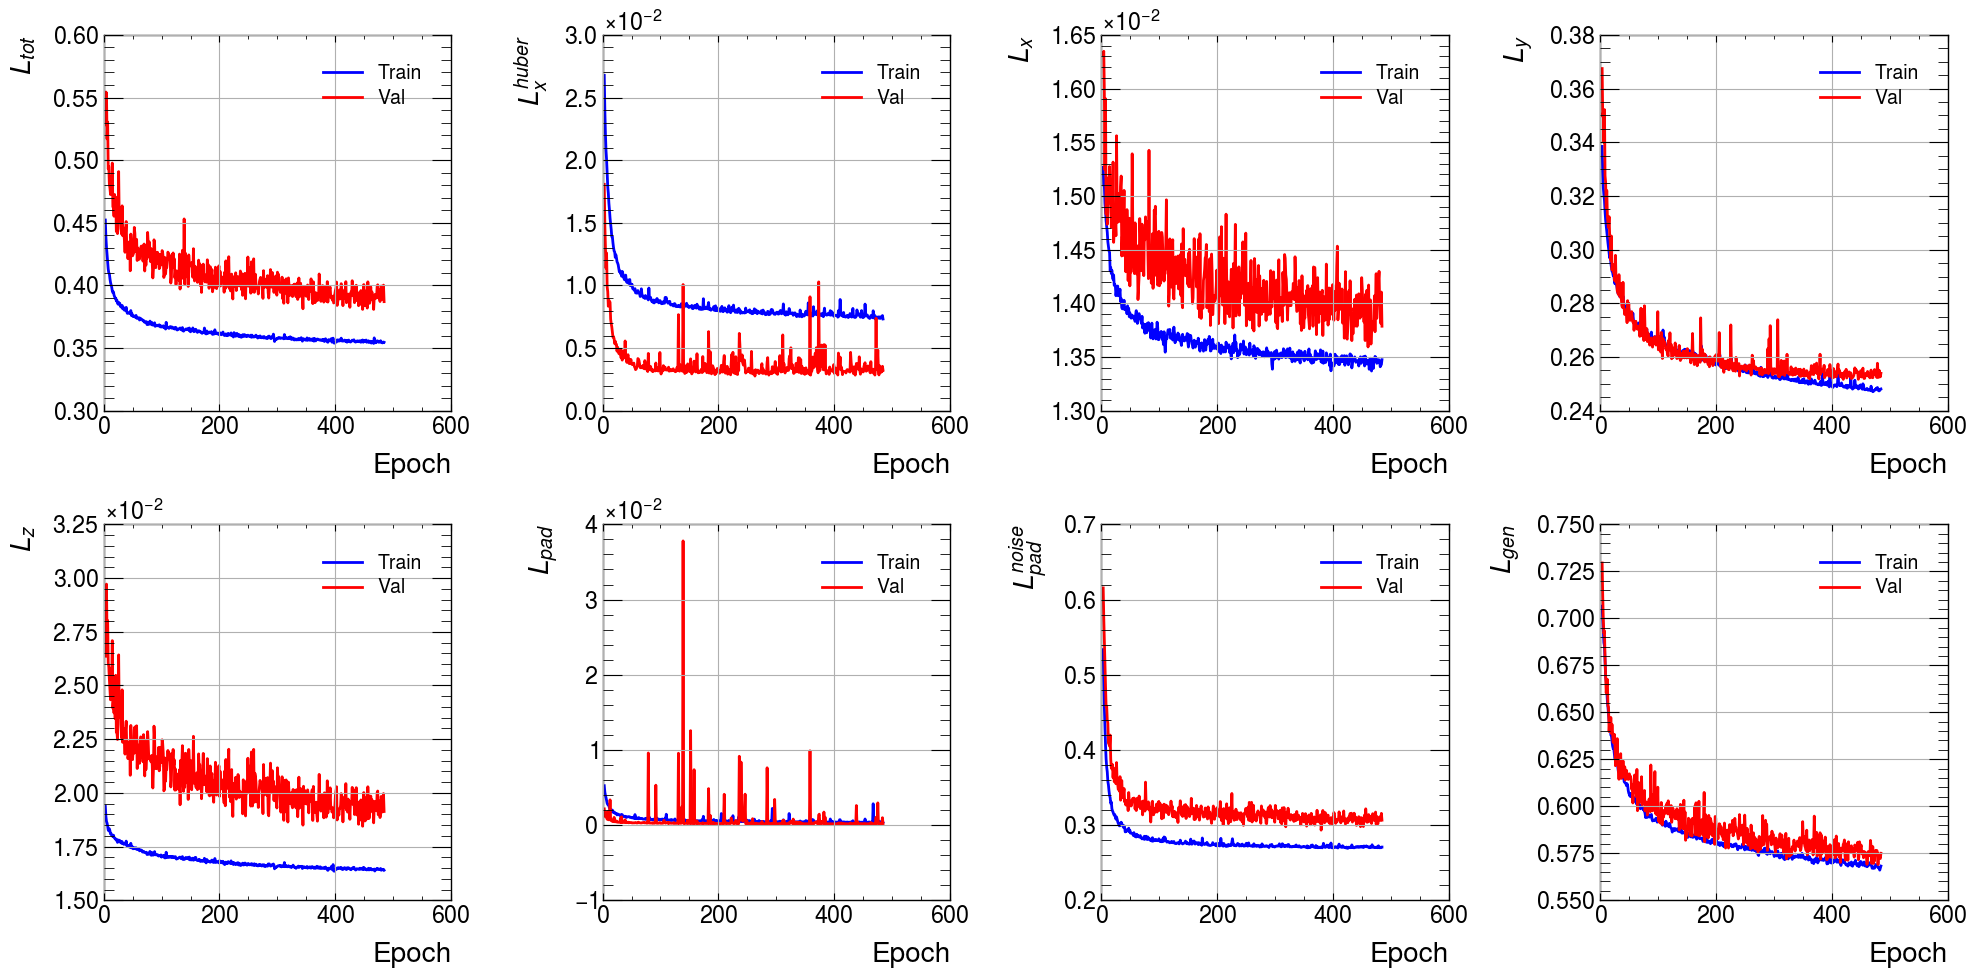


Final Training Losses (Epoch 484):
  Total Loss: 0.354643
  L_x: 0.013476
  L_x_huber: 0.007325
  L_y: 0.248121
  L_z: 0.016398
  L_pad: 0.000359
  L_pad_noise: 0.270745
  L_x_gen: 0.568187

Final Validation Losses:
  Total Loss: 0.387070
  L_x: 0.013787
  L_x_huber: 0.003232
  L_y: 0.253947
  L_z: 0.019133
  L_pad: 0.000201
  L_pad_noise: 0.306540
  L_x_gen: 0.575004


In [10]:
# Find all lightning_logs/version_* directories
log_dirs = glob.glob("logs/hww_inn_regressor-lep/log/version_*")
if not log_dirs:
    print("No logs found.")
else:
    # Select the largest version number (latest run)
    latest_log = max(log_dirs, key=lambda x : int(os.path.basename(x).split("_")[1]))
    metrics_path = os.path.join(latest_log, "metrics.csv")
    if not os.path.exists(metrics_path):
        print(f"No metrics.csv found in {latest_log}")
    else:
        # Read metrics
        df = pd.read_csv(metrics_path)

        # Remove rows with NaN in train_loss or val_loss
        df_clean = df.copy()
        if "train_loss" in df_clean.columns:
            df_clean_train = df_clean[df_clean["train_loss"].notna()]
        if "val_loss" in df_clean.columns:
            df_clean_val = df_clean[df_clean["val_loss"].notna()]

        # Create subplots for better visualization
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        
        # Plot 1: Total Loss
        axes[0, 0].plot(df_clean_train["epoch"][3:], df_clean_train["train_loss"][3:], label="Train", color='blue')
        axes[0, 0].plot(df_clean_val["epoch"][3:], df_clean_val["val_loss"][3:], label="Val", color='red')
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].set_ylabel("$L_{tot}$")
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Plot 2: L_x_huber (reconstruction loss)
        axes[0, 1].plot(df_clean_train["epoch"][3:], df_clean_train["L_x_huber"][3:], label="Train", color='blue')
        axes[0, 1].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x_huber"][3:], label="Val", color='red')
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("$L_{x}^{huber}$")
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # Plot 3: L_x (reconstruction loss)
        axes[0, 2].plot(df_clean_train["epoch"][3:], df_clean_train["L_x"][3:], label="Train", color='blue')
        axes[0, 2].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x"][3:], label="Val", color='red')
        axes[0, 2].set_xlabel("Epoch")
        axes[0, 2].set_ylabel("$L_{x}$")
        axes[0, 2].legend()
        axes[0, 2].grid(True)

        # Plot 3: L_y (reconstruction loss)
        axes[0, 3].plot(df_clean_train["epoch"][3:], df_clean_train["L_y"][3:], label="Train", color='blue')
        axes[0, 3].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_y"][3:], label="Val", color='red')
        axes[0, 3].set_xlabel("Epoch")
        axes[0, 3].set_ylabel("$L_y$")
        axes[0, 3].legend()
        axes[0, 3].grid(True)
        
        # Plot 3: L_z (latent space loss)
        axes[1, 0].plot(df_clean_train["epoch"][3:], df_clean_train["L_z"][3:], label="Train", color='blue')
        axes[1, 0].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_z"][3:], label="Val", color='red')
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("$L_z$")
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # Plot 5: L_pad (padding loss)
        axes[1, 1].plot(df_clean_train["epoch"][3:], df_clean_train["L_pad"][3:], label="Train", color='blue')
        axes[1, 1].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_pad"][3:], label="Val", color='red')
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("$L_{pad}$")
        axes[1, 1].legend()
        axes[1, 1].grid(True)

        # Plot 6: L_pad_noise (input reconstruction loss)
        axes[1, 2].plot(df_clean_train["epoch"][3:], df_clean_train["L_pad_noise"][3:], label="Train", color='blue')
        axes[1, 2].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_pad_noise"][3:], label="Val", color='red')
        axes[1, 2].set_xlabel("Epoch")
        axes[1, 2].set_ylabel("$L_{pad}^{noise}$")
        axes[1, 2].legend()
        axes[1, 2].grid(True)
        
        # Plot 6: L_x_gen (input reconstruction loss)
        axes[1, 3].plot(df_clean_train["epoch"][3:], df_clean_train["L_x_gen"][3:], label="Train", color='blue')
        axes[1, 3].plot(df_clean_val["epoch"][3:], df_clean_val["val_L_x_gen"][3:], label="Val", color='red')
        axes[1, 3].set_xlabel("Epoch")
        axes[1, 3].set_ylabel("$L_{gen}$")
        axes[1, 3].legend()
        axes[1, 3].grid(True)

        plt.tight_layout()
        plt.show()
        
        # Print final loss values for analysis
        print(f"\nFinal Training Losses (Epoch {df_clean_train['epoch'].iloc[-1]}):")
        print(f"  Total Loss: {df_clean_train['train_loss'].iloc[-1]:.6f}")
        print(f"  L_x: {df_clean_train['L_x'].iloc[-1]:.6f}")
        print(f"  L_x_huber: {df_clean_train['L_x_huber'].iloc[-1]:.6f}")
        print(f"  L_y: {df_clean_train['L_y'].iloc[-1]:.6f}")
        print(f"  L_z: {df_clean_train['L_z'].iloc[-1]:.6f}")
        print(f"  L_pad: {df_clean_train['L_pad'].iloc[-1]:.6f}")
        print(f"  L_pad_noise: {df_clean_train['L_pad_noise'].iloc[-1]:.6f}")
        print(f"  L_x_gen: {df_clean_train['L_x_gen'].iloc[-1]:.6f}")
        
        print(f"\nFinal Validation Losses:")
        print(f"  Total Loss: {df_clean_val['val_loss'].iloc[-1]:.6f}") 
        print(f"  L_x: {df_clean_val['val_L_x'].iloc[-1]:.6f}")
        print(f"  L_x_huber: {df_clean_val['val_L_x_huber'].iloc[-1]:.6f}")
        print(f"  L_y: {df_clean_val['val_L_y'].iloc[-1]:.6f}")
        print(f"  L_z: {df_clean_val['val_L_z'].iloc[-1]:.6f}")
        print(f"  L_pad: {df_clean_val['val_L_pad'].iloc[-1]:.6f}")
        print(f"  L_pad_noise: {df_clean_val['val_L_pad_noise'].iloc[-1]:.6f}")
        print(f"  L_x_gen: {df_clean_val['val_L_x_gen'].iloc[-1]:.6f}")

In [11]:
true_lep0_px = test_features[..., 0]
true_lep0_py = test_features[..., 1]
true_lep0_eta = test_features[..., 2]
true_lep0_e = test_features[..., 3]
true_lep1_px = test_features[..., 4]
true_lep1_py = test_features[..., 5]
true_lep1_eta = test_features[..., 6]
true_lep1_e = test_features[..., 7]

pred_lep0_px = predictions_inputs[..., 0]
pred_lep0_py = predictions_inputs[..., 1]
pred_lep0_eta = predictions_inputs[..., 2]
pred_lep0_e = predictions_inputs[..., 3]
pred_lep1_px = predictions_inputs[..., 4]
pred_lep1_py = predictions_inputs[..., 5]
pred_lep1_eta = predictions_inputs[..., 6]
pred_lep1_e = predictions_inputs[..., 7]

true_z = sample_z
pred_z = predictions_z

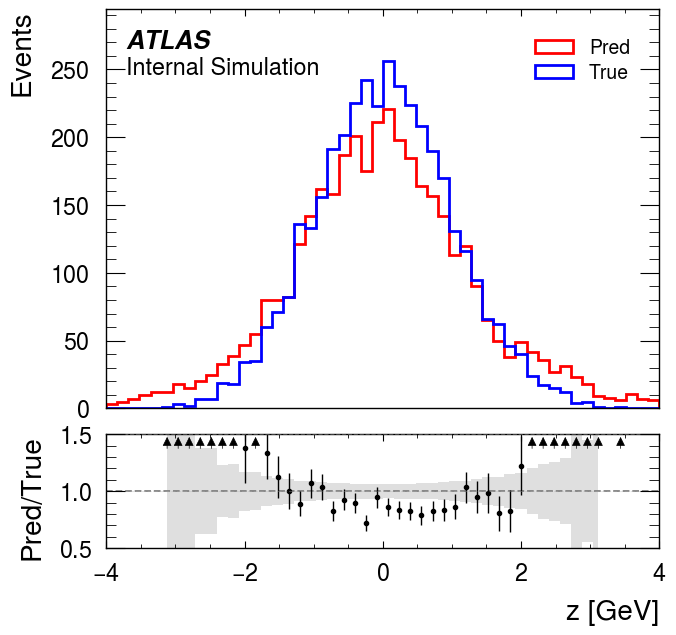

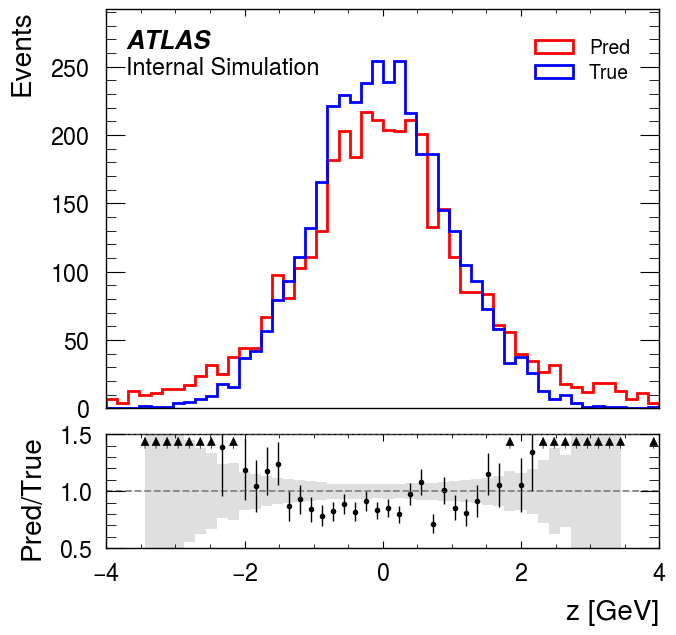

In [12]:
plot_1d_hist(pred_z[..., 0], true_z[..., 0], "z", bins_edges=np.linspace(-4, 4, 51))
plot_1d_hist(pred_z[..., -2], true_z[..., -2], "z", bins_edges=np.linspace(-4, 4, 51))

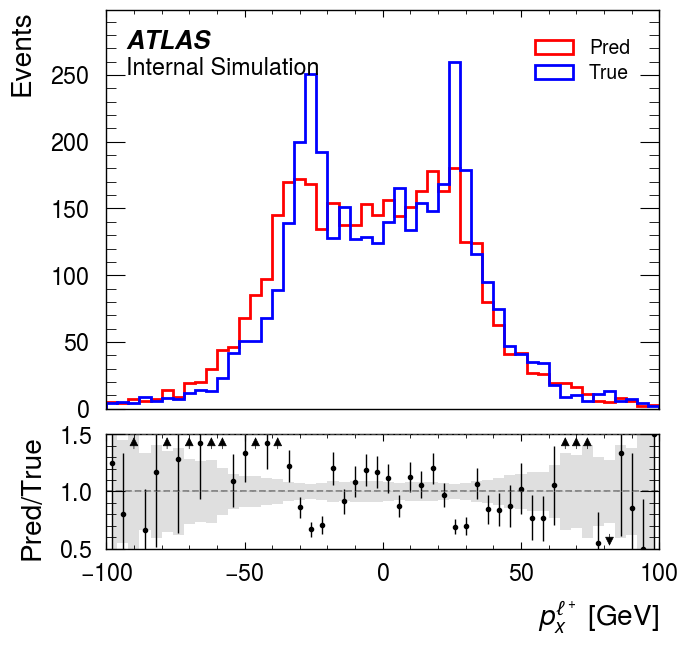

Rel err < 20%: 26.19 %


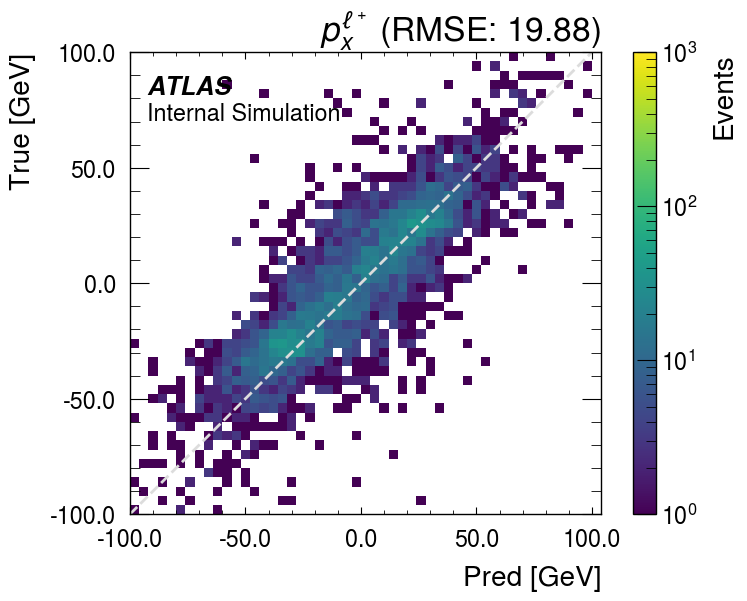

(3768,)


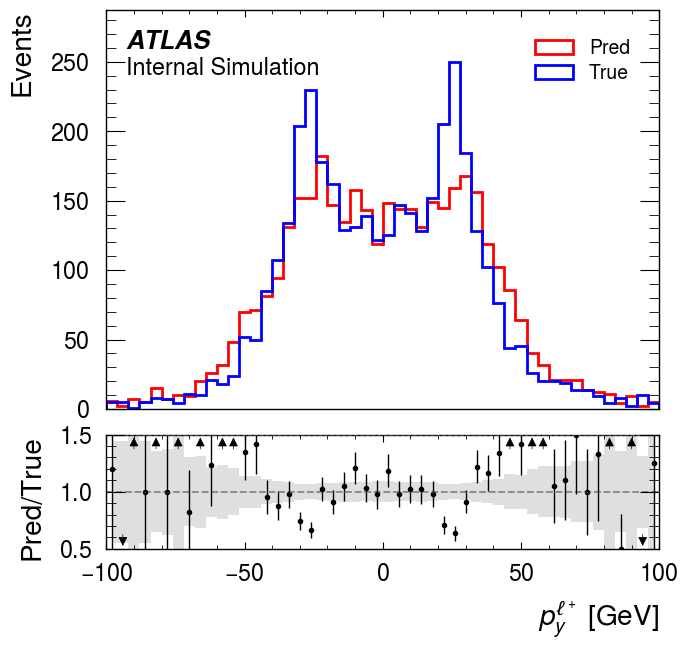

Rel err < 20%: 27.04 %


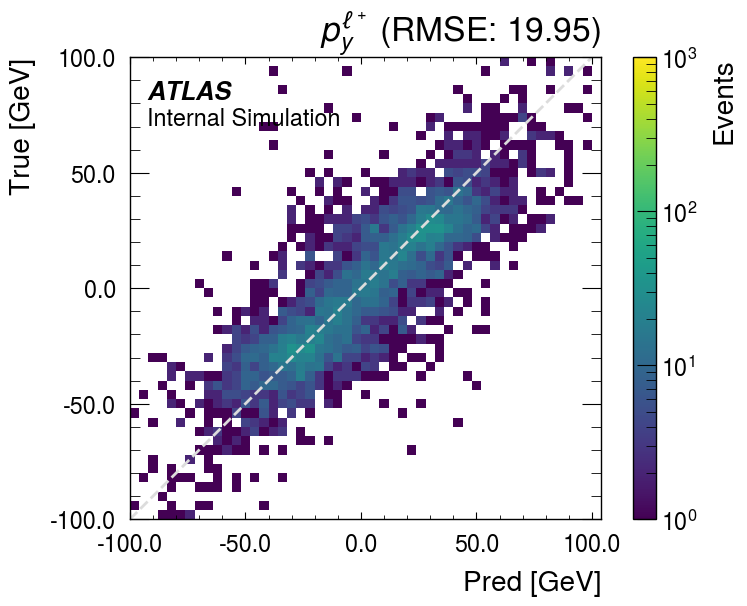

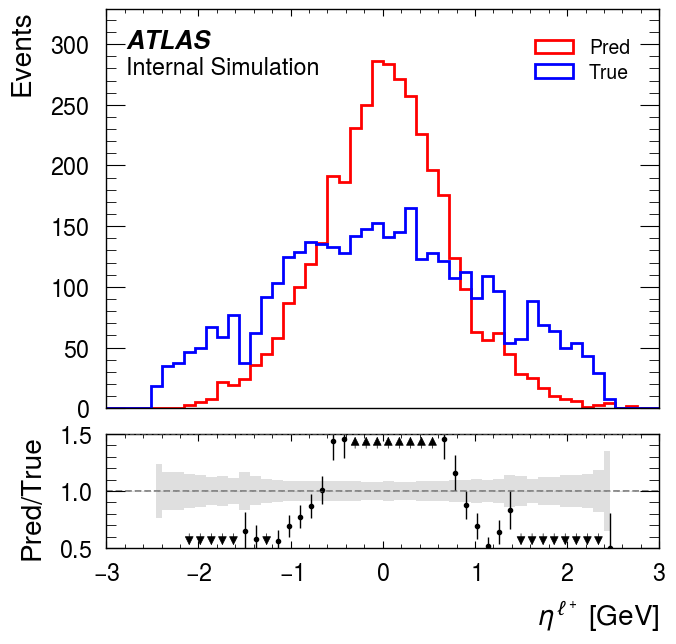

Rel err < 20%: 9.02 %


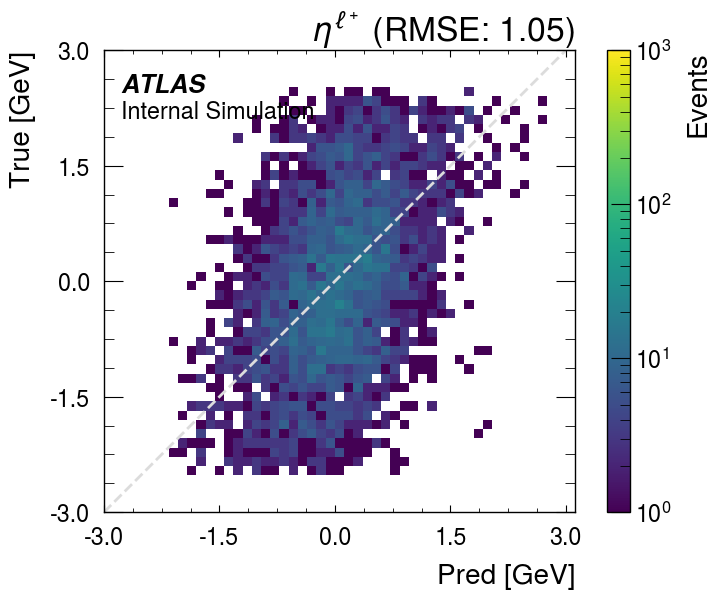

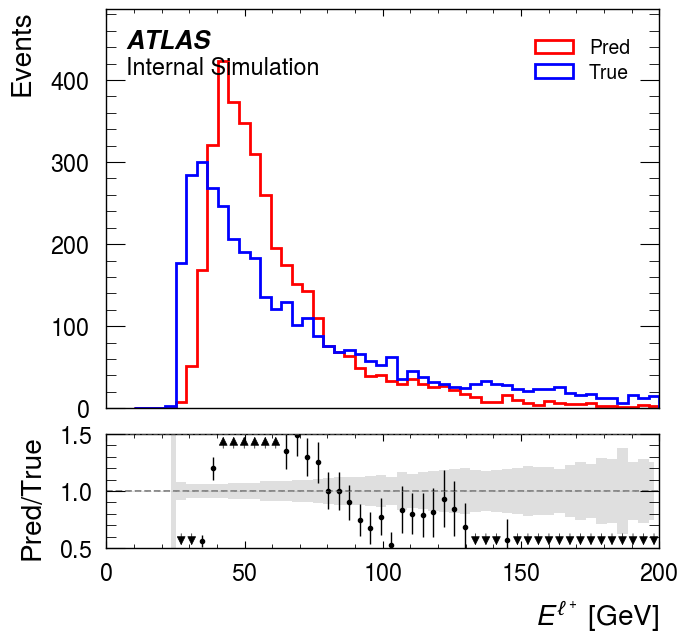

Rel err < 20%: 31.45 %


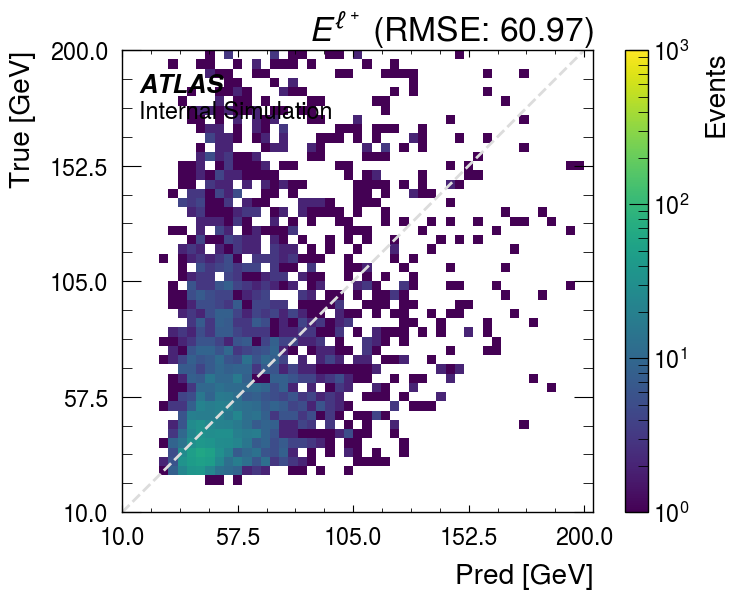

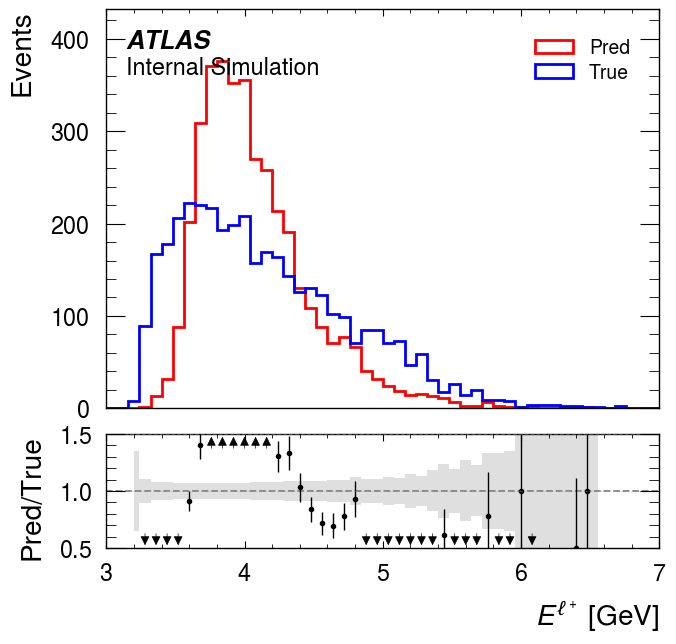

Rel err < 20%: 88.59 %


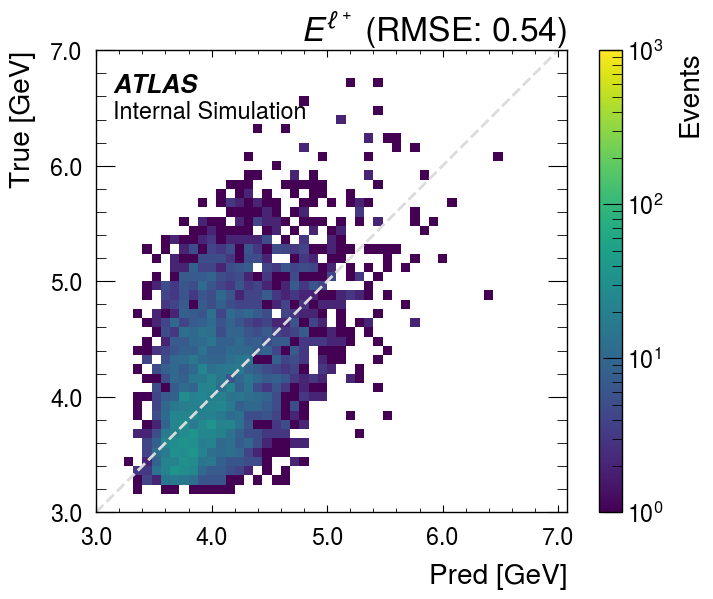

In [13]:
plot_1d_hist(pred_lep0_px, true_lep0_px, "$p^{\ell^+}_x$", bins_edges=np.linspace(-100, 100, 51))
plot_2d_hist(pred_lep0_px, true_lep0_px, "$p^{\ell^+}_x$", bins_edges=np.linspace(-100, 100, 51), log=True)
print(pred_lep0_px.shape)
plot_1d_hist(pred_lep0_py, true_lep0_py, "$p^{\ell^+}_y$", bins_edges=np.linspace(-100, 100, 51))
plot_2d_hist(pred_lep0_py, true_lep0_py, "$p^{\ell^+}_y$", bins_edges=np.linspace(-100, 100, 51), log=True)

plot_1d_hist(pred_lep0_eta, true_lep0_eta, "$\eta^{\ell^+}$", bins_edges=np.linspace(-3, 3, 51))
plot_2d_hist(pred_lep0_eta, true_lep0_eta, "$\eta^{\ell^+}$", bins_edges=np.linspace(-3, 3, 51), log=True)

plot_1d_hist(np.exp(pred_lep0_e), np.exp(true_lep0_e), "$E^{\ell^+}$", bins_edges=np.linspace(10, 200, 51))
plot_2d_hist(np.exp(pred_lep0_e), np.exp(true_lep0_e), "$E^{\ell^+}$", bins_edges=np.linspace(10, 200, 51), log=True)

plot_1d_hist(pred_lep0_e, true_lep0_e, "$E^{\ell^+}$", bins_edges=np.linspace(3, 7, 51))
plot_2d_hist(pred_lep0_e, true_lep0_e, "$E^{\ell^+}$", bins_edges=np.linspace(3, 7, 51), log=True)

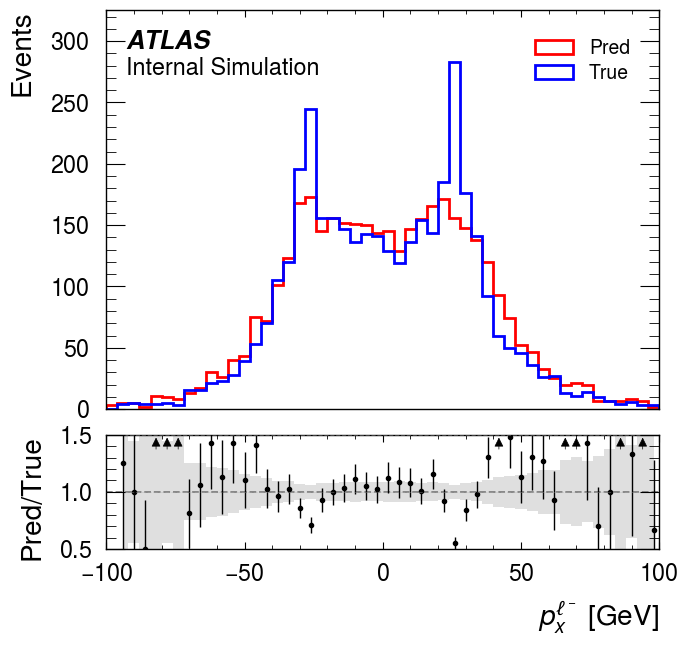

Rel err < 20%: 26.41 %


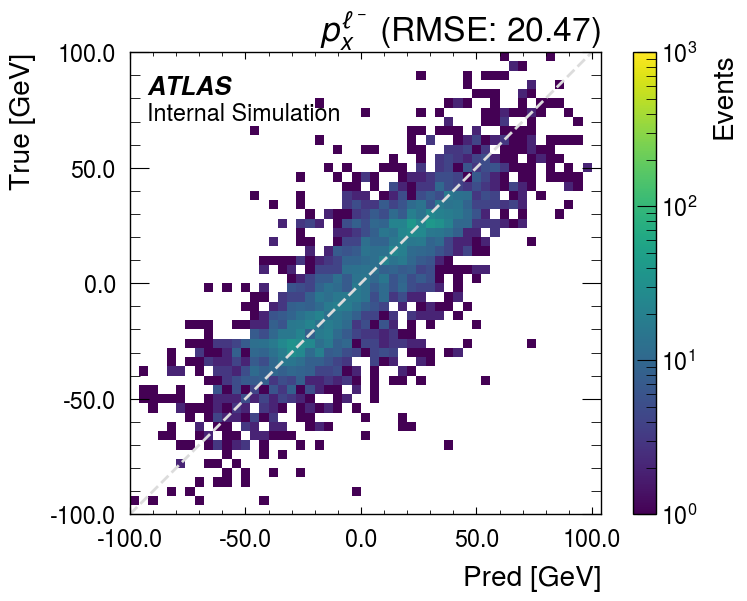

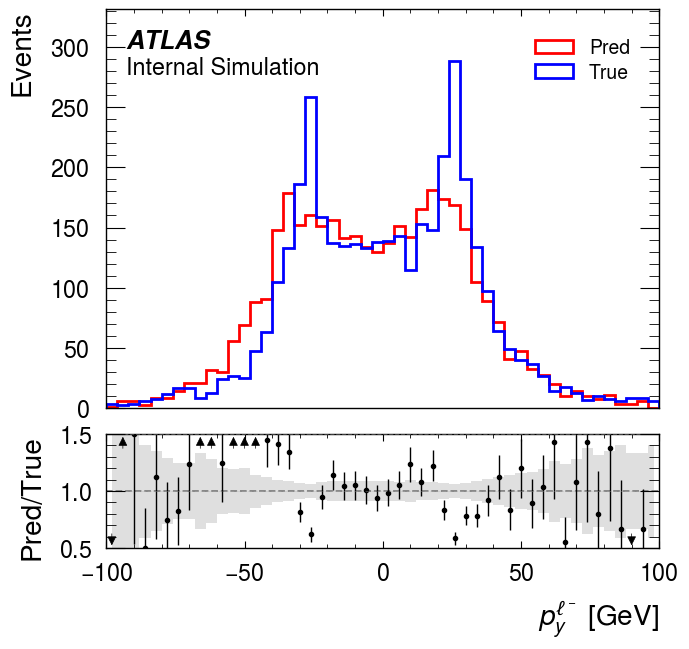

Rel err < 20%: 27.79 %


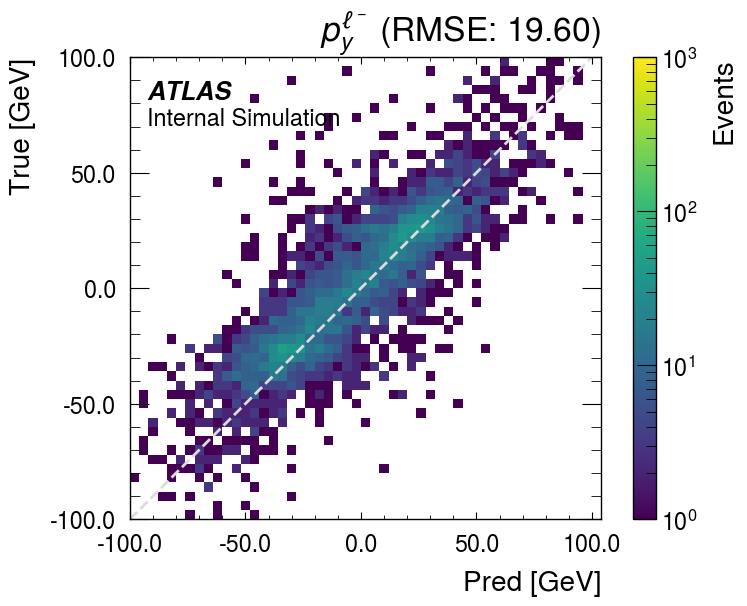

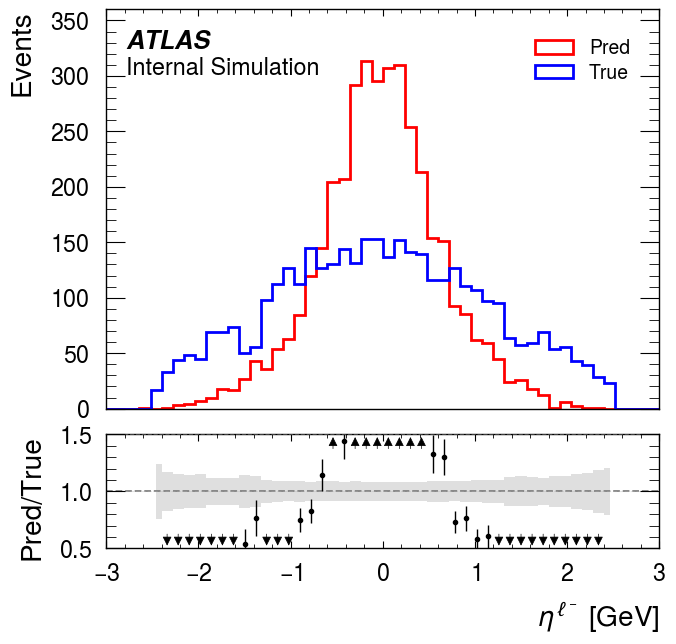

Rel err < 20%: 8.28 %


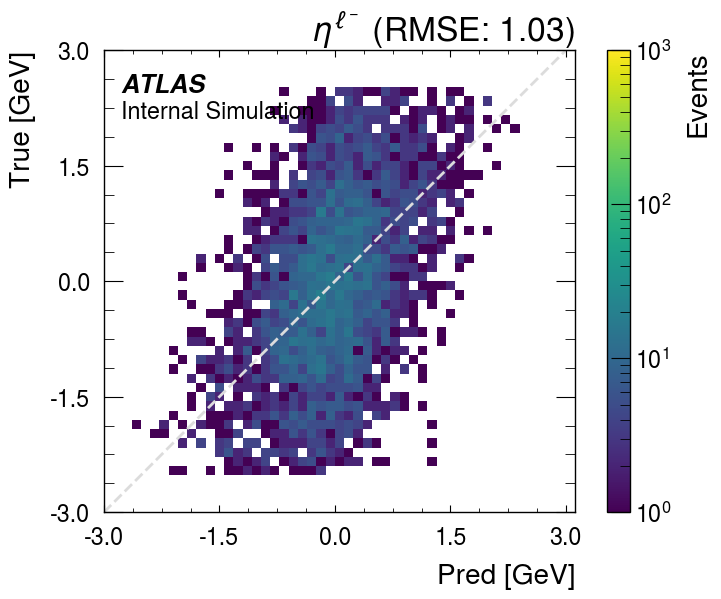

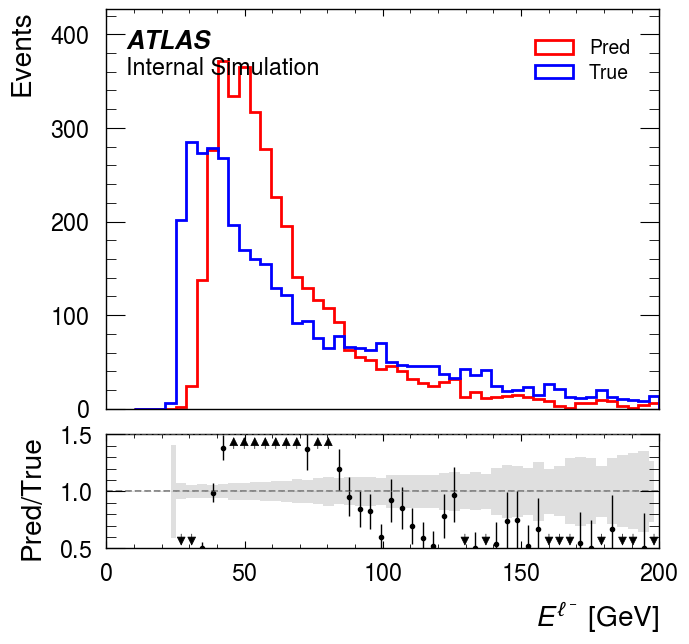

Rel err < 20%: 29.27 %


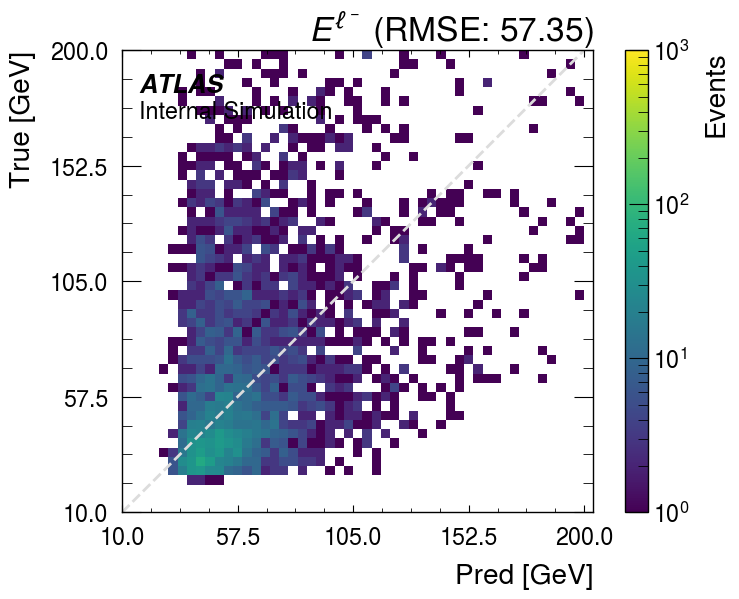

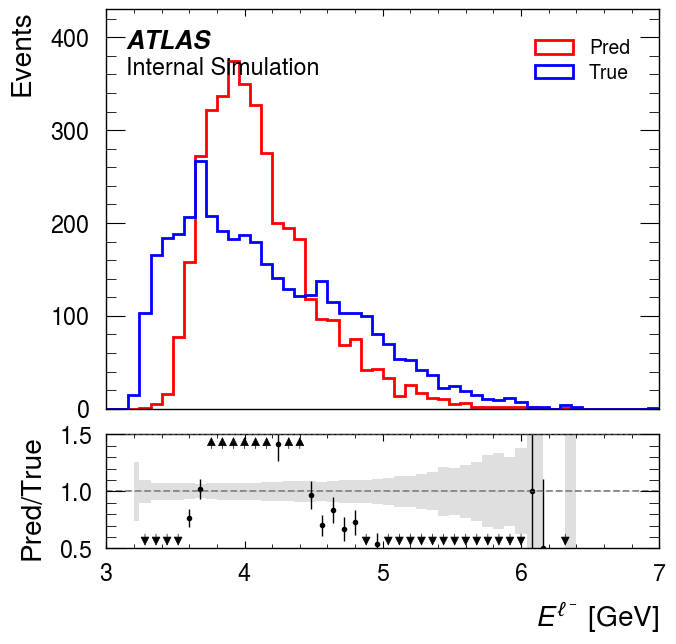

Rel err < 20%: 89.20 %


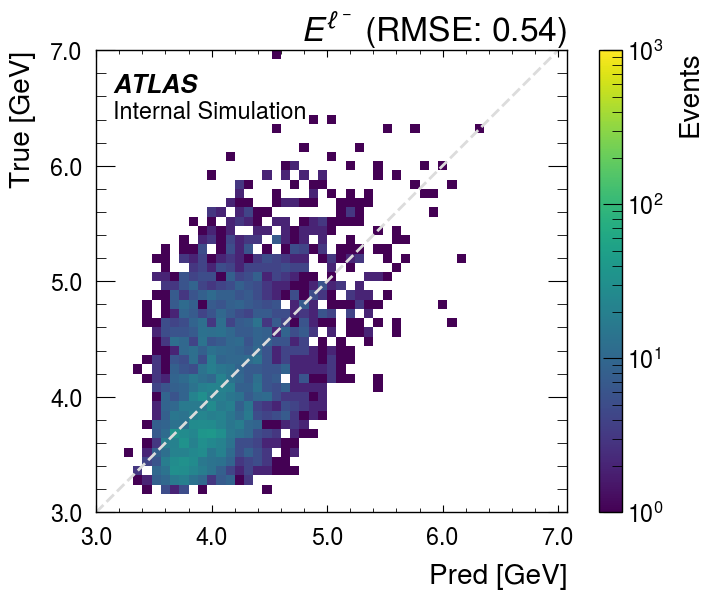

In [14]:
plot_1d_hist(pred_lep1_px, true_lep1_px, "$p^{\ell^-}_x$", bins_edges=np.linspace(-100, 100, 51))
plot_2d_hist(pred_lep1_px, true_lep1_px, "$p^{\ell^-}_x$", bins_edges=np.linspace(-100, 100, 51), log=True)

plot_1d_hist(pred_lep1_py, true_lep1_py, "$p^{\ell^-}_y$", bins_edges=np.linspace(-100, 100, 51))
plot_2d_hist(pred_lep1_py, true_lep1_py, "$p^{\ell^-}_y$", bins_edges=np.linspace(-100, 100, 51), log=True)

plot_1d_hist(pred_lep1_eta, true_lep1_eta, "$\eta^{\ell^-}$", bins_edges=np.linspace(-3, 3, 51))
plot_2d_hist(pred_lep1_eta, true_lep1_eta, "$\eta^{\ell^-}$", bins_edges=np.linspace(-3, 3, 51), log=True)

plot_1d_hist(np.exp(pred_lep1_e), np.exp(true_lep1_e), "$E^{\ell^-}$", bins_edges=np.linspace(10, 200, 51))
plot_2d_hist(np.exp(pred_lep1_e), np.exp(true_lep1_e), "$E^{\ell^-}$", bins_edges=np.linspace(10, 200, 51), log=True)

plot_1d_hist(pred_lep1_e, true_lep1_e, "$E^{\ell^-}$", bins_edges=np.linspace(3, 7, 51))
plot_2d_hist(pred_lep1_e, true_lep1_e, "$E^{\ell^-}$", bins_edges=np.linspace(3, 7, 51), log=True)

In [15]:
pred_l0_theta = predictions[..., 0]
pred_l0_phi = np.arctan2(predictions[..., 1], predictions[..., 2]) / np.pi
pred_l1_theta = predictions[..., 3]
pred_l1_phi = np.arctan2(predictions[..., 4], predictions[..., 5]) / np.pi

true_l0_theta = true_labels[..., 0]
true_l0_phi = np.arctan2(true_labels[..., 1], true_labels[..., 2]) / np.pi
true_l1_theta = true_labels[..., 3]
true_l1_phi = np.arctan2(true_labels[..., 4], true_labels[..., 5]) / np.pi

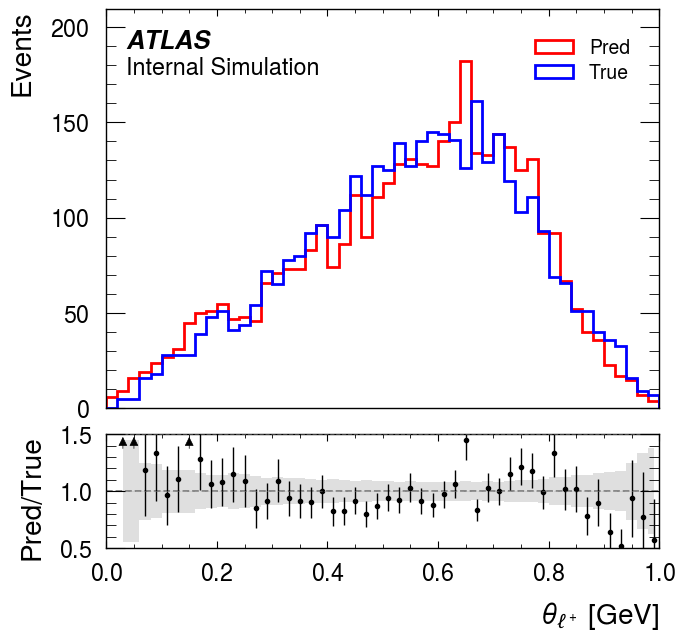

Rel err < 20%: 36.54 %


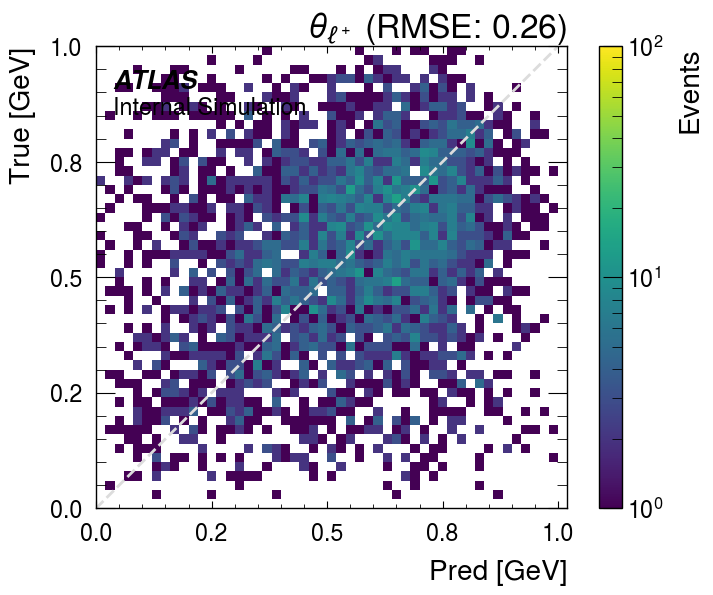

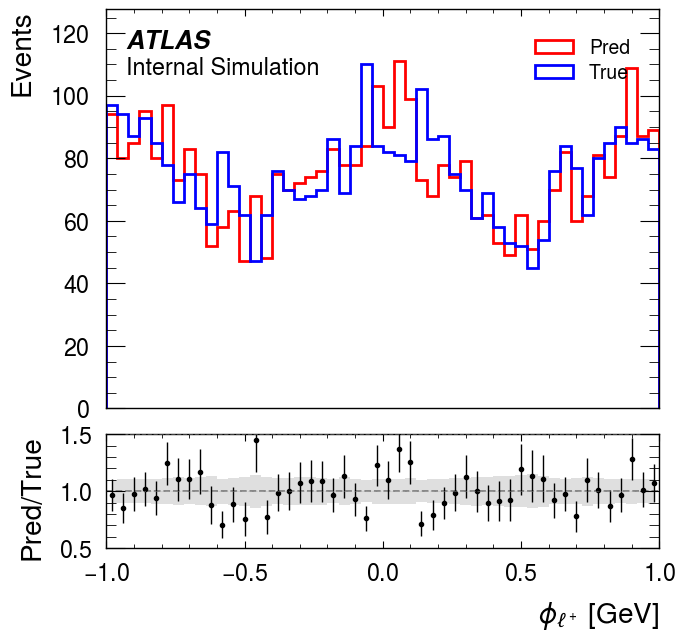

Rel err < 20%: 16.08 %


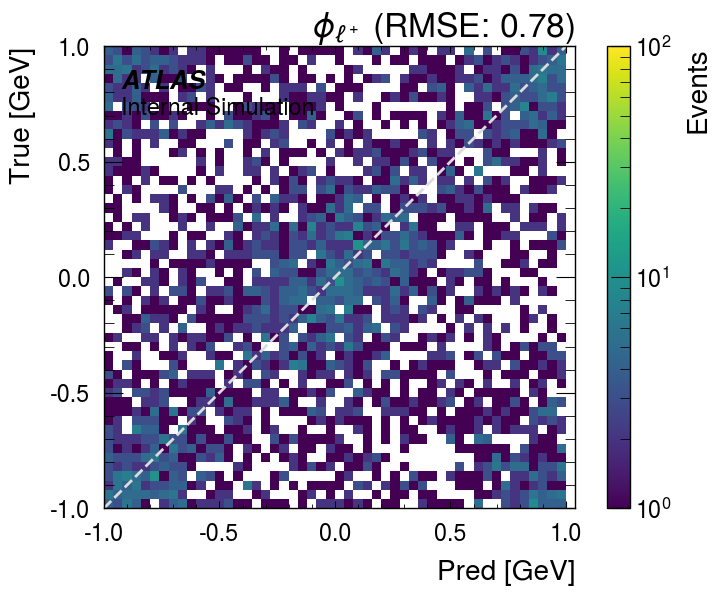

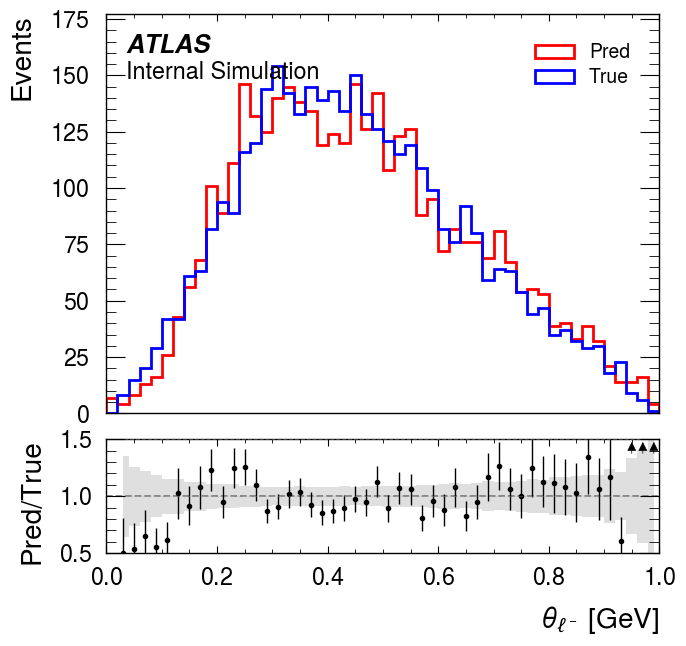

Rel err < 20%: 32.14 %


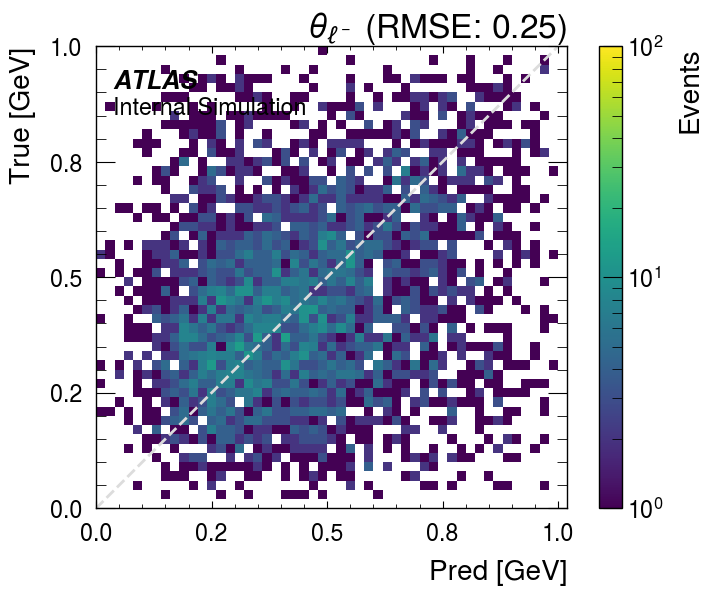

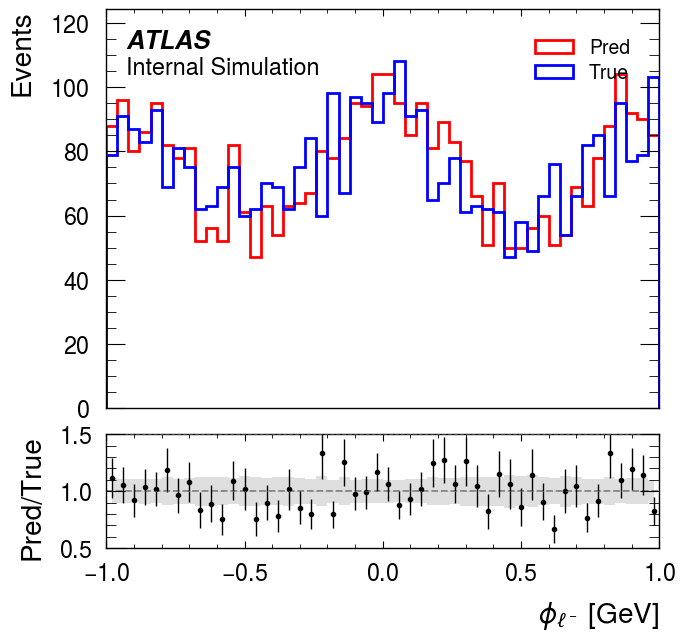

Rel err < 20%: 15.37 %


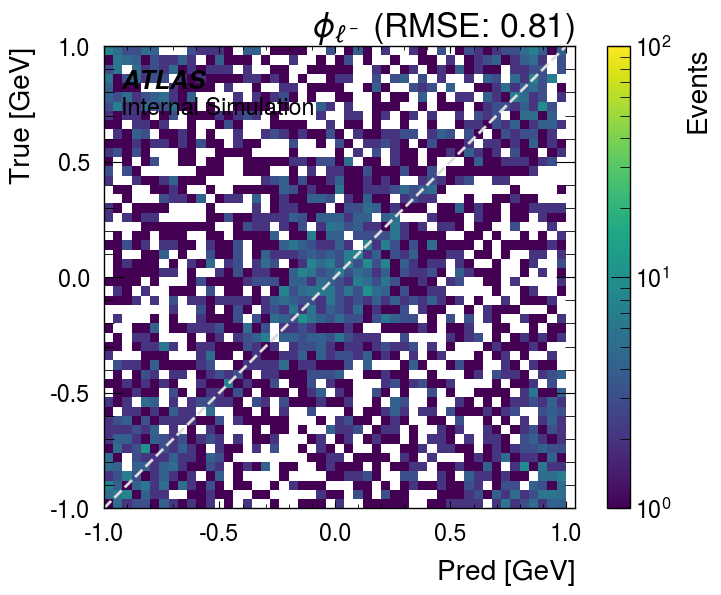

In [16]:
plot_1d_hist(pred_l0_theta, true_l0_theta, "$\\theta_{\ell^+}$", np.linspace(0, 1, 51))
plot_2d_hist(pred_l0_theta, true_l0_theta, "$\\theta_{\ell^+}$", np.linspace(0, 1, 51), log=True, vmax=1e2)

plot_1d_hist(pred_l0_phi, true_l0_phi, "$\\phi_{\ell^+}$", np.linspace(-1, 1, 51))
plot_2d_hist(pred_l0_phi, true_l0_phi, "$\\phi_{\ell^+}$", np.linspace(-1, 1, 51), log=True, vmax=1e2)

plot_1d_hist(pred_l1_theta, true_l1_theta, "$\\theta_{\ell^-}$", np.linspace(0, 1, 51))
plot_2d_hist(pred_l1_theta, true_l1_theta, "$\\theta_{\ell^-}$", np.linspace(0, 1, 51), log=True, vmax=1e2)

plot_1d_hist(pred_l1_phi, true_l1_phi, "$\\phi_{\ell^-}$", np.linspace(-1, 1, 51))
plot_2d_hist(pred_l1_phi, true_l1_phi, "$\\phi_{\ell^-}$", np.linspace(-1, 1, 51), log=True, vmax=1e2)

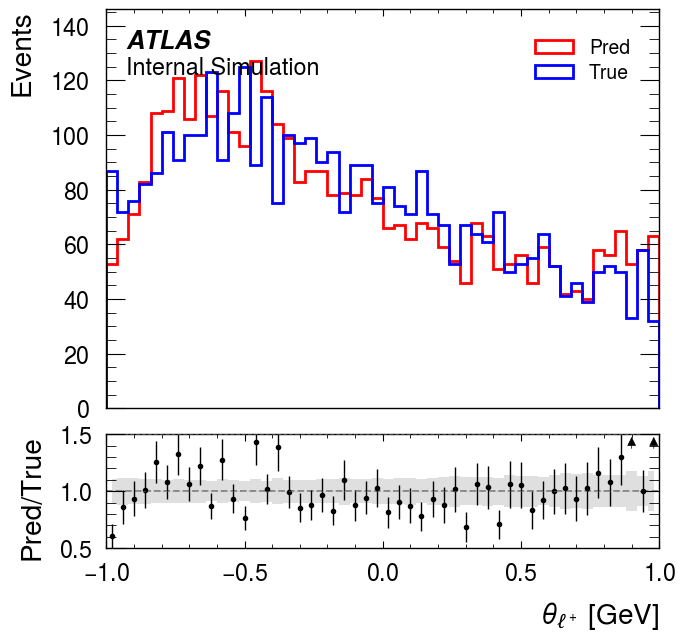

Rel err < 20%: 14.20 %


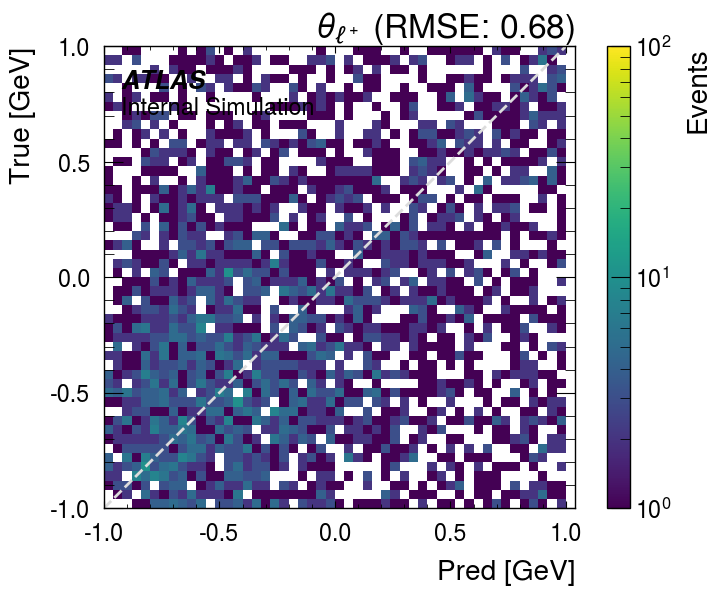

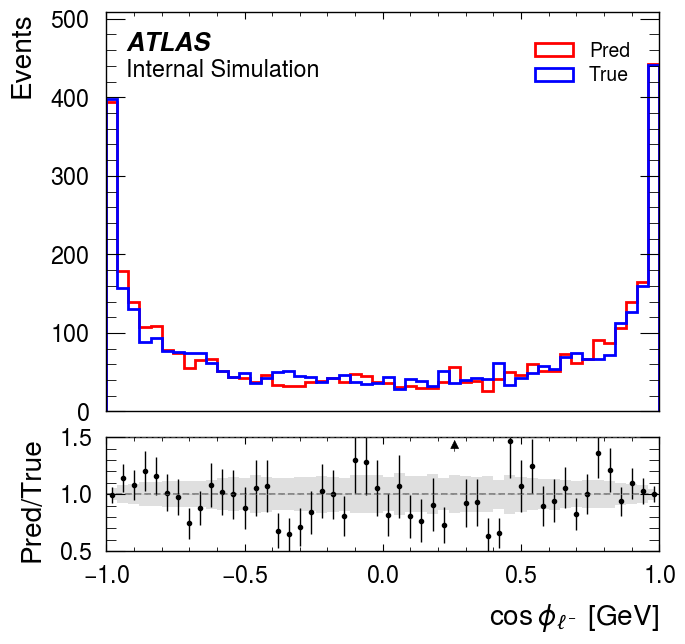

Rel err < 20%: 28.16 %


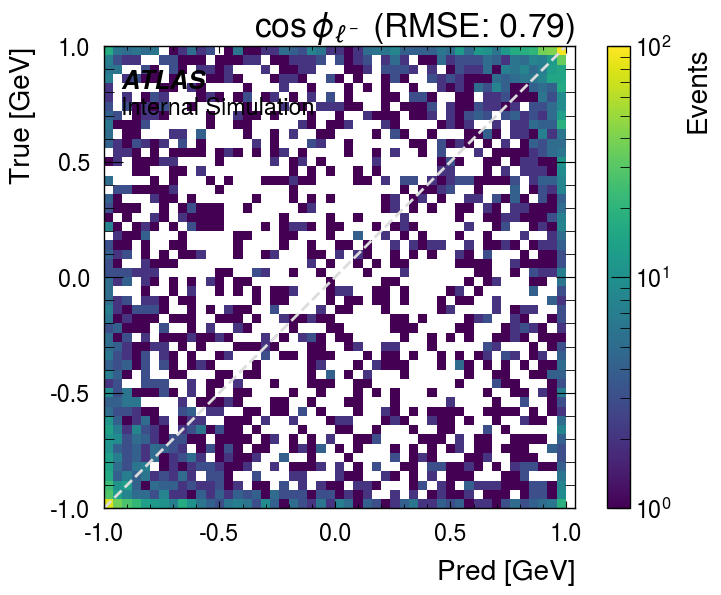

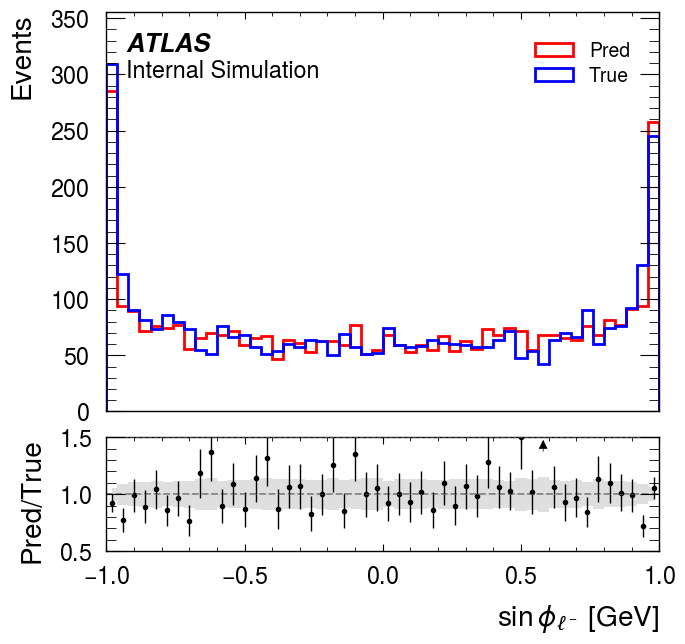

Rel err < 20%: 13.83 %


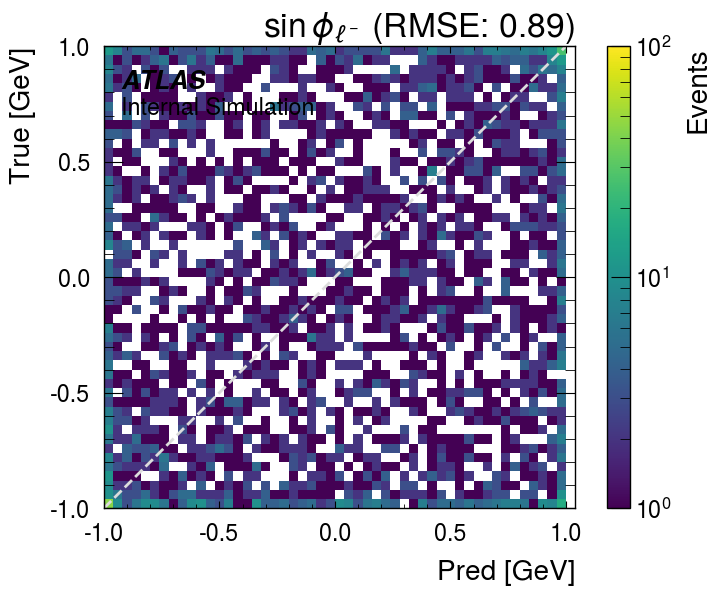

Rel err < 20%: 6.90 %


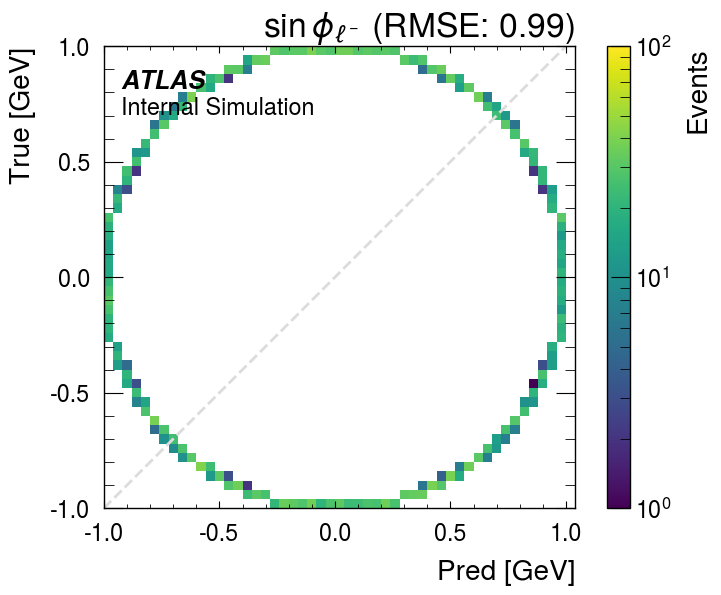

In [17]:
# TODO: deal wiht cyclic variables
plot_1d_hist(np.cos(pred_l0_theta*np.pi), np.cos(true_l0_theta*np.pi), "$\\theta_{\ell^+}$", np.linspace(-1, 1, 51))
plot_2d_hist(np.cos(pred_l0_theta*np.pi), np.cos(true_l0_theta*np.pi), "$\\theta_{\ell^+}$", np.linspace(-1, 1, 51), log=True, vmax=1e2)
plot_1d_hist(np.cos(pred_l1_phi*np.pi), np.cos(true_l1_phi*np.pi), "$\\cos\\phi_{\ell^-}$", np.linspace(-1, 1, 51))
plot_2d_hist(np.cos(pred_l1_phi*np.pi), np.cos(true_l1_phi*np.pi), "$\\cos\\phi_{\ell^-}$", np.linspace(-1, 1, 51), log=True, vmax=1e2)
plot_1d_hist(np.sin(pred_l1_phi*np.pi), np.sin(true_l1_phi*np.pi), "$\\sin\\phi_{\ell^-}$", np.linspace(-1, 1, 51))
plot_2d_hist(np.sin(pred_l1_phi*np.pi), np.sin(true_l1_phi*np.pi), "$\\sin\\phi_{\ell^-}$", np.linspace(-1, 1, 51), log=True, vmax=1e2)

plot_2d_hist(np.sin(pred_l1_phi*np.pi), np.cos(pred_l1_phi*np.pi), "$\\sin\\phi_{\ell^-}$", np.linspace(-1, 1, 51), log=True, vmax=1e2)

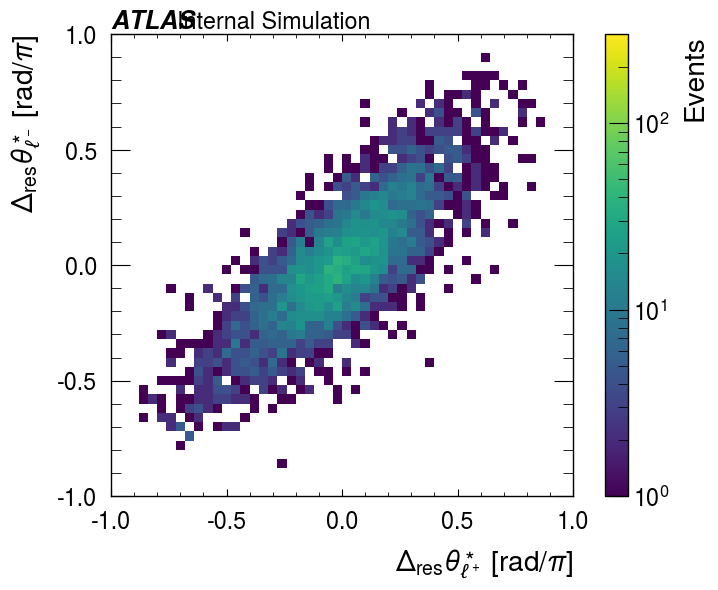

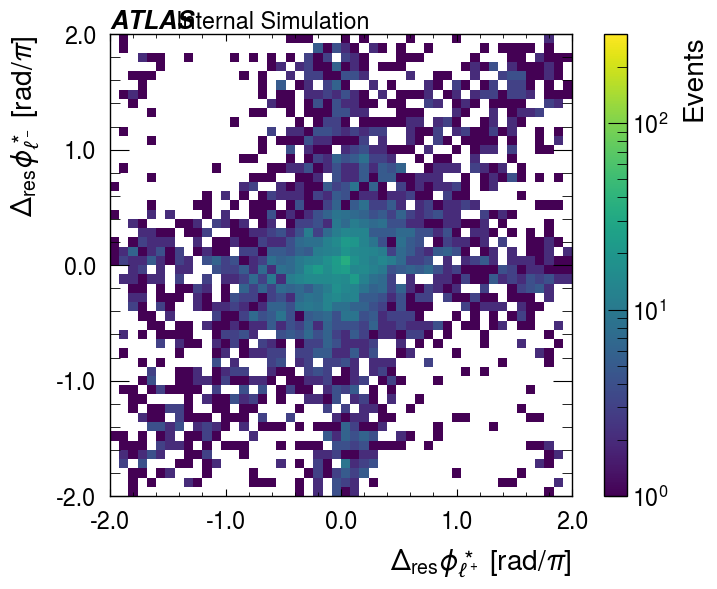

In [18]:
l0_theta_res = pred_l0_theta - true_l0_theta
l1_theta_res = pred_l1_theta - true_l1_theta
plot_2d_res_hist(l0_theta_res, l1_theta_res, name_pos=r"$\theta^\ast_{\ell^+}$", name_neg=r"$\theta^\ast_{\ell^-}$", bins_edges=np.linspace(-1, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)

l0_phi_res = pred_l0_phi - true_l0_phi
l1_phi_res = pred_l1_phi - true_l1_phi
plot_2d_res_hist(l0_phi_res, l1_phi_res, name_pos=r"$\phi^\ast_{\ell^+}$", name_neg=r"$\phi^\ast_{\ell^-}$", bins_edges=np.linspace(-2, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=3e2)